<a href="https://colab.research.google.com/github/Sujal710/vlm-finetuning/blob/main/finetuning_vlm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U -q git+https://github.com/huggingface/trl.git bitsandbytes peft qwen-vl-utils trackio
# Tested with trl==0.22.0.dev0, bitsandbytes==0.47.0, peft==0.17.1, qwen-vl-utils==0.0.11, trackio==0.2.8

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 18.3 MB/s eta 0:00:00


In [2]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

In [4]:
def format_data(sample):
    return {
      "images": [sample["image"]],
      "messages": [

          {
              "role": "system",
              "content": [
                  {
                      "type": "text",
                      "text": system_message
                  }
              ],
          },
          {
              "role": "user",
              "content": [
                  {
                      "type": "image",
                      "image": sample["image"],
                  },
                  {
                      "type": "text",
                      "text": sample['query'],
                  }
              ],
          },
          {
              "role": "assistant",
              "content": [
                  {
                      "type": "text",
                      "text": sample["label"][0]
                  }
              ],
          },
      ]
      }

In [21]:
def format_data(sample):
    image = sample["image"].convert("RGB")
    image = image.resize((336, 336))

    return {
        "images": [image],          # keep one image here
        "messages": [
            {
                "role": "system",
                "content": [{"type": "text", "text": system_message}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},   # <-- removed "image": image here, just a placeholder
                    {"type": "text", "text": sample["query"]},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": sample["label"][0]}],
            },
        ],
    }

In [22]:
from datasets import load_dataset

dataset_id = "HuggingFaceM4/ChartQA"
train_dataset, eval_dataset, test_dataset = load_dataset(
    dataset_id, split=["train[:5%]", "val[:5%]", "test[:5%]"]
)

# Apply formatting here, not inside the trainer
train_dataset = train_dataset.map(format_data, remove_columns=train_dataset.column_names)
eval_dataset  = eval_dataset.map(format_data,  remove_columns=eval_dataset.column_names)

Map:   0%|          | 0/1415 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_dataset

dataset_id = "HuggingFaceM4/ChartQA"
train_dataset, eval_dataset, test_dataset = load_dataset(dataset_id, split=['train[:5%]', 'val[:5%]', 'test[:5%]'])

In [ ]:
from datasets import load_dataset
dataset_id="HuggingFaceM4/ChartQA"
train_dataset,eval_dataset,test_dataset=load_dataset(dataset_id,split=['train[:10]','val[:10%]','test[:10%]'])

In [ ]:
train_dataset

Dataset({
    features: ['image', 'query', 'label', 'human_or_machine'],
    num_rows: 2830
})

In [7]:
train_dataset = [format_data(sample) for sample in train_dataset]
eval_dataset = [format_data(sample) for sample in eval_dataset]
test_dataset = [format_data(sample) for sample in test_dataset]

KeyError: 'image'

In [ ]:
train_dataset

[{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>],
  'messages': [{'role': 'system',
    'content': [{'type': 'text',
      'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
   {'role': 'user',
    'content': [{'type': 'image',
      'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>},
     {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]},
   {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}]},
 {'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359

In [8]:
import torch
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor

model_id = "Qwen/Qwen2-VL-7B-Instruct"

In [ ]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

processor = Qwen2VLProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
import gc
import time
import torch

def clear_memory():
    # Delete variables if they exist in the current global scope
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    if 'bnb_config' in globals(): del globals()['bnb_config']
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()

GPU allocated memory: 0.00 GB
GPU reserved memory: 0.00 GB


In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration,Qwen2VLProcessor
model_id="Qwen/Qwen2-VL-7B-Instruct"


In [ ]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    text_input = processor.apply_chat_template(
        sample['messages'][1:2],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample['messages'])

    # Prepare the inputs for the model
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)  # Move inputs to the specified device

    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

In [ ]:
# Example of how to call the method with sample:
output = generate_text_from_sample(model, processor, train_dataset[0])
output

KeyboardInterrupt: 

In [ ]:
train_dataset[0]


{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>],
 'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>},
    {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}]}

In [ ]:
train_dataset[0]['messages'][1:2]


[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>},
   {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]}]

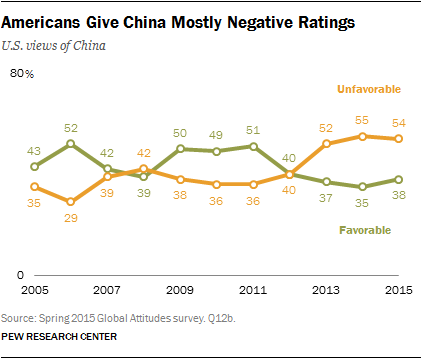

In [ ]:
train_dataset[0]['images'][0]


In [ ]:
sample['messages'][1:2]

NameError: name 'sample' is not defined

In [ ]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    text_input = processor.apply_chat_template(
        sample['messages'][1:2],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample['messages'])

    # Prepare the inputs for the model
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)  # Move inputs to the specified device

    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

In [ ]:
from qwen_vl_utils import process_vision_
def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
  text_input=processor.apply_chat_template(sample['messages'][1:2],tokenize=False,add_generation_prompt=True)
  image_inputs,_=process_vision_info(sample['messages'])
  model_inputs=processor(text=[text_input],images=image_inputs,return_tensors="pt").to(device)
  generated_ids=model.generate(**model_inputs,max_new_tokens=max_new_tokens)
  trimmed_generated_ids=[out_ids[len(in_ids):] for in_ids,out_ids in zip(model_inputs.input_ids,generated_ids)]
  output_text=processor.batch_decode(trimmed_generated_ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)
  return output_text[0]


ImportError: cannot import name 'process_vision_' from 'qwen_vl_utils' (/usr/local/lib/python3.12/dist-packages/qwen_vl_utils/__init__.py)

In [ ]:
my_form = {"Name": "John", "Age": 25, "City": "Delhi"}

In [ ]:
print(**my_form)

TypeError: 'Name' is an invalid keyword argument for print()

In [ ]:
# Define a simple function that ACCEPTS these arguments
def show_details(Name, Age, City):
    print(Name)
    print(Age)
    print(City)

# Your dictionary
my_form = {"Name": "John", "Age": 25, "City": "Delhi"}

# Call with **
show_details(**my_form)

# Output:
# John
# 25
# Delhi

John
25
Delhi


In [ ]:
# Define a simple function that ACCEPTS these arguments
def show_details(Name, Age, City):
    print(Name)
    print(Age)
    print(City)

# Your dictionary
my_form = {"Name": "John", "Age": 25, "City": "Delhi"}

# Call with **
show_details(my_form)

# Output:
# John
# 25
# Delhi

TypeError: show_details() missing 2 required positional arguments: 'Age' and 'City'

In [10]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map='cuda:0',
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,
    low_cpu_mem_usage=True  # avoids loading full model into RAM first
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [11]:
processor = Qwen2VLProcessor.from_pretrained(model_id)

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:

from peft import LoraConfig

# Configure LoRA
peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=2,
    bias="none",
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM",
)

In [ ]:
from peft import LoraConfig
peft_config=LoraConfig(lora_alpha=16,lora_dropout=0.05,r=8,bias="none",target_modules=["q_proj", "v_proj"],task_type="CAUSAL_LM")

In [ ]:
import psutil, torch

print(f"GPU VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CPU RAM: {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"RAM available: {psutil.virtual_memory().available / 1e9:.1f} GB")

GPU VRAM: 15.6 GB
CPU RAM: 13.6 GB
RAM available: 5.2 GB


In [ ]:
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

0.0 GB allocated
0.0 GB reserved


In [ ]:
from trl import SFTTrainer

training_args=SFTConfig(output_dir='qwen2-7b-instruct-trl-sft-ChartQA',num_train_epochs=3,per_device_train_batch_size=4,per_device_eval_batch_size=4,gradient_accumulation_steps=8,gradient_checkpointing_kwargs={"use_reentrant": False},optim="adamw_torch_fused",learning_rate=2e-4,logging_steps=10,eval_steps=10,eval_steps=10,eval_strategy='steps',save_strategy='steps',save_steps=20,bf16=True,max_grad_norm=0.3,warmup_ratio=0.03,report_to='trackio')

In [23]:
from trl import SFTConfig
training_args = SFTConfig(
    output_dir="qwen2-7b-instruct-trl-sft-ChartQA",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=32,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",
    learning_rate=2e-4,
    logging_steps=10,
    eval_steps=10,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    bf16=True,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    dataset_kwargs={"skip_prepare_dataset": True},
    max_length=512,    # <-- correct name for TRL 1.0.0.dev0
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [24]:
from trl import SFTTrainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    processing_class=processor   # <-- moved here
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
import trl
print(trl.__version__)

import inspect
print(inspect.signature(trl.SFTTrainer.__init__))

1.0.0.dev0
(self, model: 'str | PreTrainedModel | PeftModel', args: trl.trainer.sft_config.SFTConfig | transformers.training_args.TrainingArguments | None = None, data_collator: collections.abc.Callable[[list[typing.Any]], dict[str, typing.Any]] | None = None, train_dataset: datasets.arrow_dataset.Dataset | datasets.iterable_dataset.IterableDataset | None = None, eval_dataset: datasets.arrow_dataset.Dataset | datasets.iterable_dataset.IterableDataset | dict[str, datasets.arrow_dataset.Dataset | datasets.iterable_dataset.IterableDataset] | None = None, processing_class: transformers.tokenization_utils_base.PreTrainedTokenizerBase | transformers.processing_utils.ProcessorMixin | None = None, compute_loss_func: collections.abc.Callable | None = None, compute_metrics: collections.abc.Callable[[transformers.trainer_utils.EvalPrediction], dict] | None = None, callbacks: list[transformers.trainer_callback.TrainerCallback] | None = None, optimizers: tuple[torch.optim.optimizer.Optimizer | None

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
